In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('netflix_titles.csv')

In [17]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [23]:
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

In [15]:
df.shape

(8807, 12)

In [18]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [19]:

df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [24]:
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
porcentaje_nulos.round(2)

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64

In [21]:
df.duplicated().sum()

np.int64(0)

In [25]:
df['director'] = df['director'].fillna('Desconocido')
df['cast'] = df['cast'].fillna('Desconocido')
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [26]:
df = df.dropna(subset=['date_added', 'rating'])

In [27]:
df.shape

(8793, 12)

Text(0, 0.5, 'Cantidad')

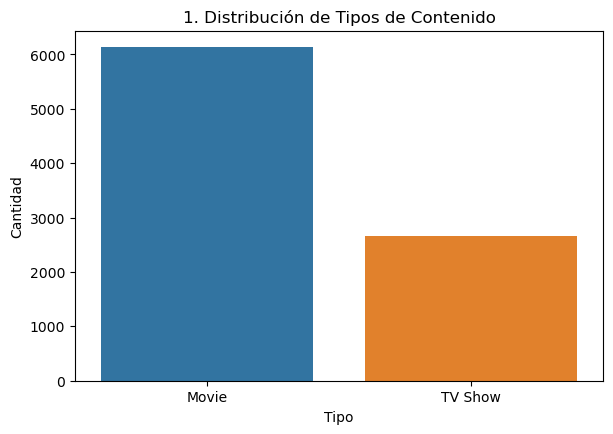

In [33]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.countplot(df, x='type', hue='type')
plt.title('Distribución de Tipos de Contenido')
plt.xlabel('Tipo')
plt.ylabel('Cantidad')

Text(0, 0.5, 'País')

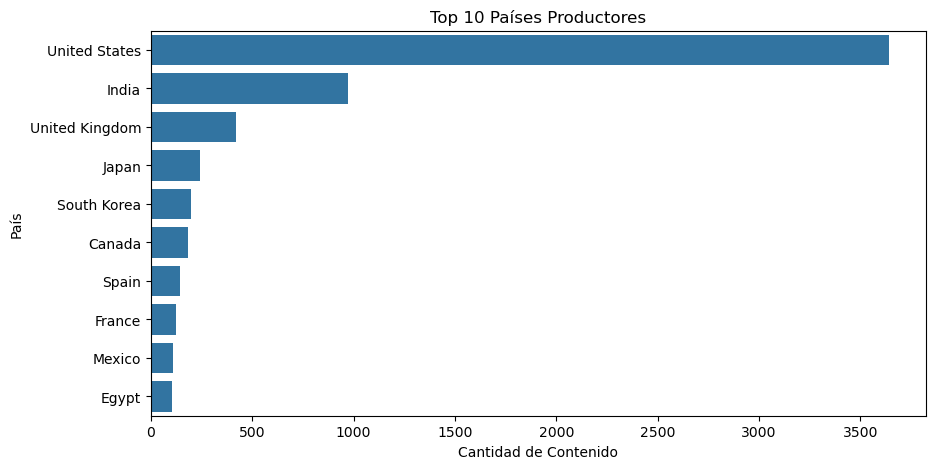

In [53]:
plt.figure(figsize=(10,5))
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Países Productores')
plt.xlabel('Cantidad de Contenido')
plt.ylabel('País')

Text(0, 0.5, 'Cantidad')

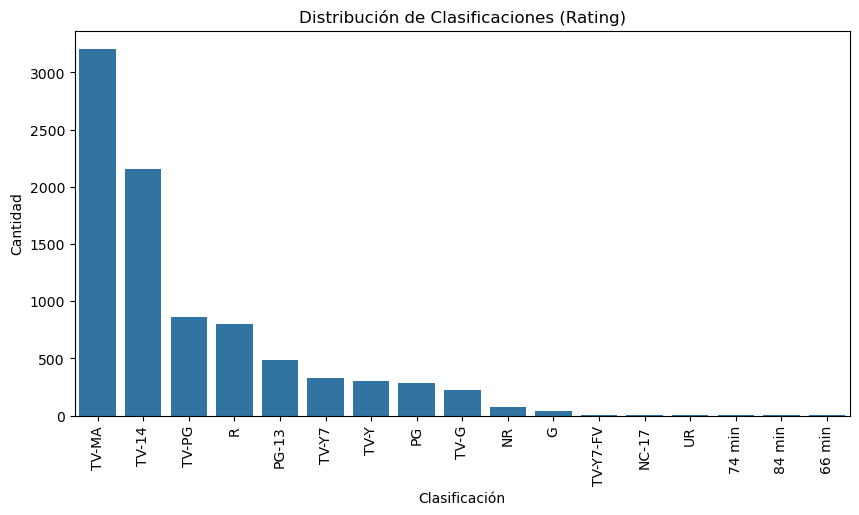

In [52]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index)
plt.title('Distribución de Clasificaciones (Rating)')
plt.xticks(rotation=90)
plt.xlabel('Clasificación')
plt.ylabel('Cantidad')

Text(0, 0.5, 'Cantidad')

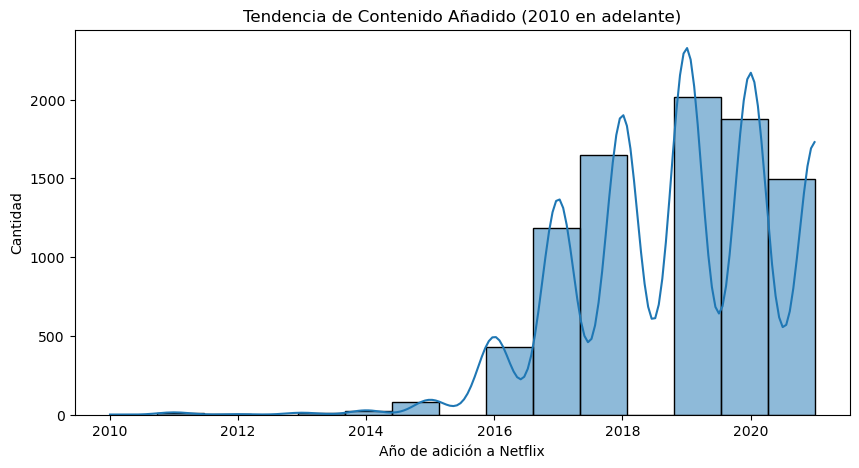

In [55]:
plt.figure(figsize=(10,5))

#estoy extrayendo el año de la colñumna year_added para referencia

df.loc[:, 'year_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce').dt.year
sns.histplot(data=df[df['year_added'] >= 2010], x='year_added', bins=15, kde=True)
plt.title('Tendencia de Contenido Añadido (2010 en adelante)')
plt.xlabel('Año de adición a Netflix')
plt.ylabel('Cantidad')

# Conclusiones derivadas del análisis.

**Conclusiones:**
1. **Preferencia de formato:** La plataforma tiene una clara inclinación hacia las películas en comparación con las series de televisión, siendo históricamente el formato dominante en su catálogo.
2. **Dominio geográfico:** Estados Unidos es, por un margen significativo, el mayor productor de contenido disponible en la plataforma, seguido de lejos por países como India y el Reino Unido.
3. **Público objetivo:** La distribución de clasificaciones (*ratings*) muestra que la gran mayoría del contenido está dirigido a audiencias maduras (TV-MA) y adolescentes (TV-14), lo que indica que el enfoque principal de la plataforma no es el contenido exclusivamente infantil.
4. **Crecimiento del catálogo:** Existe un patrón de crecimiento exponencial en la cantidad de contenido añadido a la plataforma a partir del año 2015, alcanzando su pico alrededor de 2019-2020.